In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("data/processed/leakage_free_dataset.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (250000, 28)


,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Historical_Maintenance_Cost,Impact_on_Efficiency,Days_Since_Last_Maintenance,Brake_Condition,Maintenance_Required
0,1,4,2016.263210,1,4,4,1,0,2,12156.999890,14134.916000,8856.297726,88.187864,39.766979,5.290568,90.838404,0.688063,82.617827,0.000000,0.000000,0.000000,42.834041,0.001632,193.789075,0.072093,53.741213,0,0
1,0,2,2016.101678,1,5,3,2,0,3,14921.423040,13161.594650,7915.782384,90.827148,37.269779,6.470528,98.972817,0.858262,89.485681,0.102551,1.696143,0.561199,42.828402,0.008061,591.537215,0.101045,62.670749,0,0
2,3,3,2011.648228,1,4,0,2,0,1,19723.877880,9844.764975,5884.328371,88.566975,37.255419,8.205853,80.778262,1.344360,91.016870,1.318466,0.000000,0.000000,29.492107,0.008887,602.883899,0.111896,76.867576,1,0
3,4,0,2020.812445,0,5,1,0,2,0,5175.324145,3499.397353,494.375580,99.434739,38.598132,8.899863,87.467459,2.041878,86.231550,0.162311,0.000000,0.184538,44.711910,0.006513,75.840733,0.107671,65.890269,1,0
4,4,1,2022.314726,2,4,2,2,2,3,2120.124439,6078.939605,1380.182251,93.293504,37.227710,8.245804,80.282667,1.450554,102.884309,1.060079,0.000000,0.897322,50.780901,0.008521,577.261393,0.077573,0.000000,1,0


In [3]:
X = df.drop("Maintenance_Required", axis=1)

y = df["Maintenance_Required"]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (250000, 27)
Target : (250000,)


In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [5]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
25,Days_Since_Last_Maintenance,0.125111
23,Historical_Maintenance_Cost,0.115485
24,Impact_on_Efficiency,0.107923
16,Vibration_Levels,0.079001
14,Fuel_Consumption,0.068646
15,Battery_Status,0.062306
17,Oil_Quality,0.059587
22,Sensor_Packet_Loss_Rate,0.052610
21,CAN_Message_Rate_Hz,0.038031
12,Engine_Temperature,0.036453


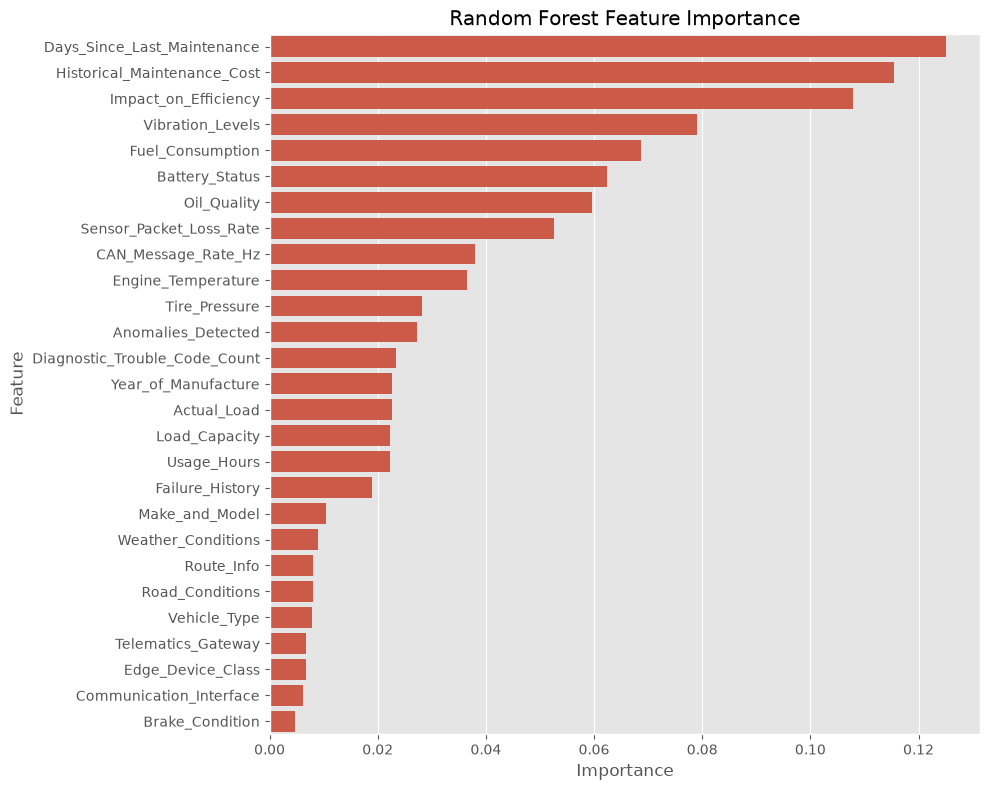

In [6]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [7]:
selected_features = [

    # Vehicle Information
    "Make_and_Model",
    "Vehicle_Type",
    "Year_of_Manufacture",

    # Road Analysis
    "Road_Conditions",
    "Weather_Conditions",
    "Route_Info",

    # Vehicle Usage
    "Usage_Hours",
    "Load_Capacity",
    "Actual_Load",

    # Engine Health
    "Engine_Temperature",
    "Fuel_Consumption",
    "Battery_Status",
    "Oil_Quality",
    "Vibration_Levels",
    "Tire_Pressure",

    # Diagnostics
    "Failure_History",
    "Anomalies_Detected",
    "Diagnostic_Trouble_Code_Count",
    "CAN_Message_Rate_Hz",
    "Sensor_Packet_Loss_Rate",

    # Target
    "Maintenance_Required"
]

In [8]:
final_df = df[selected_features]

print("Final Dataset Shape :", final_df.shape)

final_df.head()

Final Dataset Shape : (250000, 21)


,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Road_Conditions,Weather_Conditions,Route_Info,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Fuel_Consumption,Battery_Status,Oil_Quality,Vibration_Levels,Tire_Pressure,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Required
0,1,4,2016.263210,4,4,1,12156.999890,14134.916000,8856.297726,88.187864,5.290568,90.838404,82.617827,0.688063,39.766979,0.000000,0.000000,0.000000,42.834041,0.001632,0
1,0,2,2016.101678,3,5,1,14921.423040,13161.594650,7915.782384,90.827148,6.470528,98.972817,89.485681,0.858262,37.269779,0.102551,1.696143,0.561199,42.828402,0.008061,0
2,3,3,2011.648228,0,4,1,19723.877880,9844.764975,5884.328371,88.566975,8.205853,80.778262,91.016870,1.344360,37.255419,1.318466,0.000000,0.000000,29.492107,0.008887,0
3,4,0,2020.812445,1,5,0,5175.324145,3499.397353,494.375580,99.434739,8.899863,87.467459,86.231550,2.041878,38.598132,0.162311,0.000000,0.184538,44.711910,0.006513,0
4,4,1,2022.314726,2,4,2,2120.124439,6078.939605,1380.182251,93.293504,8.245804,80.282667,102.884309,1.450554,37.227710,1.060079,0.000000,0.897322,50.780901,0.008521,0


In [9]:
print("Selected Features:\n")

for feature in final_df.columns[:-1]:
    print(feature)

Selected Features:

Make_and_Model
Vehicle_Type
Year_of_Manufacture
Road_Conditions
Weather_Conditions
Route_Info
Usage_Hours
Load_Capacity
Actual_Load
Engine_Temperature
Fuel_Consumption
Battery_Status
Oil_Quality
Vibration_Levels
Tire_Pressure
Failure_History
Anomalies_Detected
Diagnostic_Trouble_Code_Count
CAN_Message_Rate_Hz
Sensor_Packet_Loss_Rate


In [10]:
final_df.to_csv(
    "data/processed/final_selected_dataset.csv",
    index=False
)

print("Feature-selected dataset saved successfully!")

Feature-selected dataset saved successfully!


In [11]:
saved_df = pd.read_csv("data/processed/final_selected_dataset.csv")

print(saved_df.shape)

saved_df.head()

(250000, 21)


,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Road_Conditions,Weather_Conditions,Route_Info,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Fuel_Consumption,Battery_Status,Oil_Quality,Vibration_Levels,Tire_Pressure,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Required
0,1,4,2016.263210,4,4,1,12156.999890,14134.916000,8856.297726,88.187864,5.290568,90.838404,82.617827,0.688063,39.766979,0.000000,0.000000,0.000000,42.834041,0.001632,0
1,0,2,2016.101678,3,5,1,14921.423040,13161.594650,7915.782384,90.827148,6.470528,98.972817,89.485681,0.858262,37.269779,0.102551,1.696143,0.561199,42.828402,0.008061,0
2,3,3,2011.648228,0,4,1,19723.877880,9844.764975,5884.328371,88.566975,8.205853,80.778262,91.016870,1.344360,37.255419,1.318466,0.000000,0.000000,29.492107,0.008887,0
3,4,0,2020.812445,1,5,0,5175.324145,3499.397353,494.375580,99.434739,8.899863,87.467459,86.231550,2.041878,38.598132,0.162311,0.000000,0.184538,44.711910,0.006513,0
4,4,1,2022.314726,2,4,2,2120.124439,6078.939605,1380.182251,93.293504,8.245804,80.282667,102.884309,1.450554,37.227710,1.060079,0.000000,0.897322,50.780901,0.008521,0
